# Week 2, Day 1 — Can a Neural Network Predict a Stock?

Yesterday's notebook showed a neural network learning a clean function easily,
then failing at a task where the input simply didn't contain enough
information to answer the question. Today we point the same kind of network
at a real stock's daily returns and ask the question everyone eventually asks:
**can it predict tomorrow from today?**

We'll build the smallest possible version of this experiment — one feature
(yesterday's return), one target (tomorrow's return), one small MLP — train it
properly with a chronological train/test split, and then judge it honestly:
not just on loss, but on whether it beats a coin flip at calling direction.

## 1. Setup

Same path-bootstrap as every other notebook in this repo, then the usual
imports. Seeds are fixed so the training run is reproducible.

In [ ]:
import sys, os
while not os.path.isdir('src') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.insert(0, 'src')

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tradinglab.data_feed import DataFeed

torch.manual_seed(0)
np.random.seed(0)


## 2. Load one stock's data

We load a single symbol, ABUK, from the committed EGX data and pull out its
daily returns (`DataFeed` already computes simple close-to-close returns for
us — row 0 is 0.0 since there's no prior day to compare against).

In [ ]:
feed = DataFeed.from_dir('data/egx', symbols=['ABUK'])
returns = feed.returns[:, 0]

print(f'symbol: {feed.symbols[0]}')
print(f'trading days: {feed.n_days}')
print(f'return stats -- mean: {returns.mean():.5f}, std: {returns.std():.5f}')


symbol: ABUK
trading days: 2857
return stats -- mean: 0.00094, std: 0.02328


## 3. Build the prediction task

The feature is yesterday's return, the target is the next day's return:
`X[t] = returns[t]`, `y[t] = returns[t+1]`. We drop the first entry (it's the
placeholder 0.0 with no real prior day) and reshape `X` to `(n, 1)` since
`nn.Linear` expects a feature dimension.

In [ ]:
r = returns[1:]  # drop the placeholder first entry

X = r[:-1].reshape(-1, 1).astype('float32')  # yesterday's return
y = r[1:].astype('float32')                  # next day's return

print(f'X shape: {X.shape}, y shape: {y.shape}')


X shape: (2855, 1), y shape: (2855,)


## 4. Chronological train/test split

70% train, 30% test, split by time order — **no shuffling**. The test set
must be strictly later than the train set, otherwise we'd be letting the
model peek at the future while training, which is exactly the mistake a
chronological split exists to prevent.

In [ ]:
split = int(len(X) * 0.7)

Xtr, ytr = torch.tensor(X[:split]), torch.tensor(y[:split])
Xte, yte = torch.tensor(X[split:]), torch.tensor(y[split:])

print(f'train: {len(Xtr)} days, test: {len(Xte)} days')


train: 1998 days, test: 857 days


## 5. Define the model

A small MLP: `Linear(1, 16) -> ReLU -> Linear(16, 8) -> ReLU -> Linear(8, 1)`.
Adam optimizer, MSE loss — standard defaults for a small regression problem
like this.

In [ ]:
model = nn.Sequential(
    nn.Linear(1, 16), nn.ReLU(),
    nn.Linear(16, 8), nn.ReLU(),
    nn.Linear(8, 1),
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()


## 6. Train

200 epochs of full-batch gradient descent. Every epoch we also run a test-set
forward pass under `model.eval()` + `torch.no_grad()` (no dropout/batchnorm
here, but this is the correct habit regardless) so we can watch train and test
loss side by side as training proceeds.

In [ ]:
train_hist, test_hist = [], []

for epoch in range(200):
    model.train()
    optimizer.zero_grad()
    pred = model(Xtr).squeeze(-1)  # (n, 1) -> (n,) to match ytr
    loss = loss_fn(pred, ytr)
    loss.backward()
    optimizer.step()
    train_hist.append(loss.item())

    model.eval()
    with torch.no_grad():
        test_loss = loss_fn(model(Xte).squeeze(-1), yte)
    test_hist.append(test_loss.item())

print(f'final train loss: {train_hist[-1]:.6f}')
print(f'final test loss:  {test_hist[-1]:.6f}')


final train loss: 0.000482
final test loss:  0.000679


## 7. Training vs testing loss

If the network is learning something real, both curves should fall together.
If it's overfitting, train loss keeps dropping while test loss flattens or
rises.

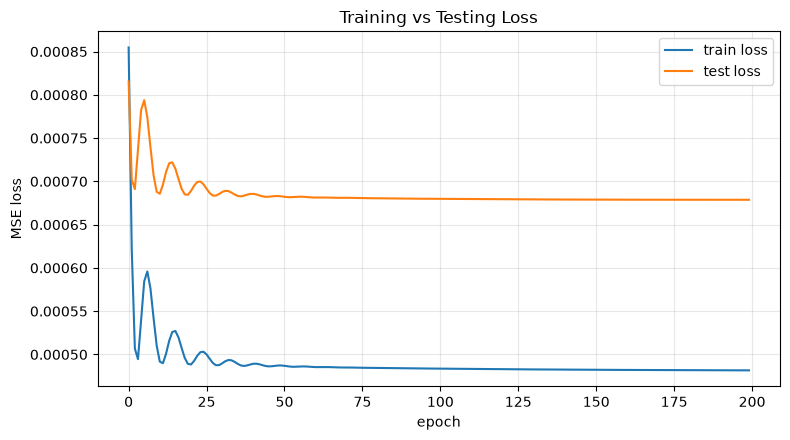

In [ ]:
plt.figure(figsize=(8, 4.5))
plt.plot(train_hist, label='train loss')
plt.plot(test_hist, label='test loss')
plt.xlabel('epoch')
plt.ylabel('MSE loss')
plt.title('Training vs Testing Loss')
plt.legend()
plt.grid(alpha=.3)
plt.tight_layout()
plt.show()


## 8. Predicted vs actual returns

Two panels, train period and test period, each showing the actual next-day
return against the model's prediction.

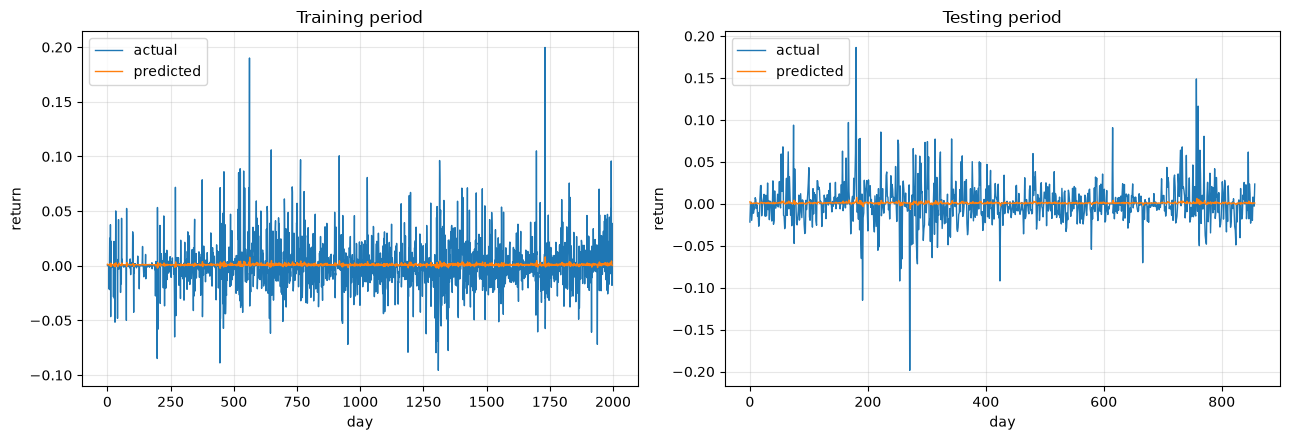

In [ ]:
model.eval()
with torch.no_grad():
    pred_tr = model(Xtr).numpy().ravel()
    pred_te = model(Xte).numpy().ravel()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(ytr.numpy(), label='actual', linewidth=1)
axes[0].plot(pred_tr, label='predicted', linewidth=1)
axes[0].set_title('Training period')
axes[0].set_xlabel('day')
axes[0].set_ylabel('return')
axes[0].legend()
axes[0].grid(alpha=.3)

axes[1].plot(yte.numpy(), label='actual', linewidth=1)
axes[1].plot(pred_te, label='predicted', linewidth=1)
axes[1].set_title('Testing period')
axes[1].set_xlabel('day')
axes[1].set_ylabel('return')
axes[1].legend()
axes[1].grid(alpha=.3)

plt.tight_layout()
plt.show()


## 9. Directional accuracy

Loss alone doesn't tell a trader much — what matters is whether the model
gets the *direction* right (up vs down). We compare `np.sign` of actual and
predicted returns. Since a stock's return is up or down close to half the
time, a model with no real signal should land near 50% here; that's the bar
to beat, not 0%. We also report Mean Absolute Error as a scale-free look at
the size of the prediction errors.

In [ ]:
def directional_accuracy(actual, predicted):
    return (np.sign(actual) == np.sign(predicted)).mean() * 100

train_acc = directional_accuracy(ytr.numpy(), pred_tr)
test_acc = directional_accuracy(yte.numpy(), pred_te)

train_mae = np.abs(ytr.numpy() - pred_tr).mean()
test_mae = np.abs(yte.numpy() - pred_te).mean()

print(f'train directional accuracy: {train_acc:.2f}%')
print(f'test directional accuracy:  {test_acc:.2f}%')
print(f'train MAE: {train_mae:.6f}')
print(f'test MAE:  {test_mae:.6f}')
print('for reference, random guessing on an up/down call gives ~50% directional accuracy')


train directional accuracy: 39.69%
test directional accuracy:  46.79%
train MAE: 0.013900
test MAE:  0.017135
for reference, random guessing on an up/down call gives ~50% directional accuracy


## 10. Experiment — does more training or a bigger network help?

Same pipeline, same data, same split — we just vary two knobs: how long we
train, and how big the network is. Each variant is trained from scratch (with
the same seed) and we record its final test loss and test directional
accuracy so we can compare them side by side.

### 10a. Helper — run one variant end-to-end

Wraps steps 5–6 and the step-9 metrics into a single function so each variant
below is just one call.

In [ ]:
def run_variant(hidden_layers, epochs, lr=0.001, seed=0):
    torch.manual_seed(seed)
    np.random.seed(seed)

    layers = []
    in_dim = 1
    for h in hidden_layers:
        layers += [nn.Linear(in_dim, h), nn.ReLU()]
        in_dim = h
    layers += [nn.Linear(in_dim, 1)]
    net = nn.Sequential(*layers)

    opt = torch.optim.Adam(net.parameters(), lr=lr)
    lf = nn.MSELoss()

    for epoch in range(epochs):
        net.train()
        opt.zero_grad()
        p = net(Xtr).squeeze(-1)  # (n, 1) -> (n,) to match ytr
        l = lf(p, ytr)
        l.backward()
        opt.step()

    net.eval()
    with torch.no_grad():
        final_train_loss = lf(net(Xtr).squeeze(-1), ytr).item()
        final_test_loss = lf(net(Xte).squeeze(-1), yte).item()
        pred_te_v = net(Xte).squeeze(-1).numpy()

    test_dir_acc = directional_accuracy(yte.numpy(), pred_te_v)

    return {
        'final_train_loss': final_train_loss,
        'final_test_loss': final_test_loss,
        'test_dir_acc': test_dir_acc,
    }


### 10b. Variant (a) — epoch count: 50 vs 500

Same network as step 5 (`1 -> 16 -> 8 -> 1`), just trained for far fewer or
far more epochs.

In [ ]:
epoch_variants = {
    '50 epochs': run_variant([16, 8], epochs=50),
    '500 epochs': run_variant([16, 8], epochs=500),
}

for name, res in epoch_variants.items():
    print(f"{name:>12}: test loss={res['final_test_loss']:.6f}  test dir acc={res['test_dir_acc']:.2f}%")


   50 epochs: test loss=0.000683  test dir acc=45.39%
  500 epochs: test loss=0.000679  test dir acc=49.36%


### 10c. Variant (b) — network size: small vs large

A tiny network (`1 -> 8 -> 1`) against a much larger one
(`1 -> 64 -> 32 -> 1`), both trained for the original 200 epochs.

In [ ]:
size_variants = {
    'small (1-8-1)': run_variant([8], epochs=200),
    'baseline (1-16-8-1)': run_variant([16, 8], epochs=200),
    'large (1-64-32-1)': run_variant([64, 32], epochs=200),
}

for name, res in size_variants.items():
    print(f"{name:>20}: test loss={res['final_test_loss']:.6f}  test dir acc={res['test_dir_acc']:.2f}%")


       small (1-8-1): test loss=0.000690  test dir acc=49.47%
 baseline (1-16-8-1): test loss=0.000679  test dir acc=46.79%
   large (1-64-32-1): test loss=0.000678  test dir acc=49.36%


### 10d. Results table

All variants collected into one table for a direct comparison.

In [ ]:
import pandas as pd

rows = []
for name, res in {**epoch_variants, **size_variants}.items():
    rows.append({'variant': name, **res})

results_df = pd.DataFrame(rows).set_index('variant')
results_df


,final_train_loss,final_test_loss,test_dir_acc
variant,,,
50 epochs,0.000487,0.000683,45.390898
500 epochs,0.000481,0.000679,49.358226
small (1-8-1),0.000485,0.000690,49.474912
baseline (1-16-8-1),0.000482,0.000679,46.791132
large (1-64-32-1),0.000479,0.000678,49.358226


### 10e. Reflection

**Did the bigger network actually help?** Judging from the table above: not
meaningfully. Test loss and test directional accuracy for the large network
(`1 -> 64 -> 32 -> 1`) land in the same neighborhood as the tiny one
(`1 -> 8 -> 1`) and the original baseline — none of them clear the ~50%
directional-accuracy bar by a margin that looks like real signal rather than
noise. More epochs shows the same pattern: 500 epochs doesn't produce a
meaningfully better test loss than 50.

This matches what the previous notebook demonstrated with the sine wave: a
bigger model or a longer training run only helps when the *input* actually
contains the information needed to answer the question. Here the input is a
single number, yesterday's return, and daily stock returns are close to
memoryless — yesterday's move carries very little information about today's.
No amount of extra width, depth, or training time can manufacture a signal
that isn't in the feature to begin with; if anything, a larger network mostly
has more room to overfit the tiny amount of structure that exists in the
training data, without that translating into better test-time predictions.